# 6단계 검증: 도메인통합 전역학습 결과의 통계적 유의성 (패션, Colab GPU용)

**이 노트북은 Colab에서 GPU로 돌리는 걸 전제로 만들었다.** 상단 메뉴 "런타임 → 런타임 유형 변경 →
하드웨어 가속기 → GPU"로 바꾸고 시작할 것. 로컬(CPU)에서는 전체 재실행에 20분 이상 걸려서 GPU로 옮김.

**목적**: `06b_timeseries_dl_손.ipynb` 섹션9(5도메인 전역학습)~섹션11(+카테고리/계절성 피처보강)에서
이미 확인한 결과 -- **naive 대비 9.8% MAE 개선(0.1406 → 0.1268)** -- 를 GPU에서 재현하고,
**이 개선이 통계적으로 유의미한지**(우연히 나온 차이가 아닌지) 검증한다.

**입력**: 왼쪽 파일 탭에 `reviews.parquet` 업로드 후 실행.

## 1. 환경 설정

In [1]:
!pip install -q "darts[torch]"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import NHiTSModel
from darts.utils.likelihood_models import QuantileRegression
from darts.utils.timeseries_generation import datetime_attribute_timeseries

DATA_PATH = "reviews.parquet"
reviews = pd.read_parquet(DATA_PATH)
print(f"reviews {len(reviews)}행 로드 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.8/815.8 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.2 MB/s eta 0:00:00
reviews 225283행 로드 완료


## 2. 5개 도메인 상품 시계열 구성 (06b 섹션9와 동일 로직)

리뷰 20건 이상, 관측기간 10개월 이상인 상품을 5개 도메인(패션/생활/화장품/IT기기/가전) 전부 모아서
전역학습 대상으로 삼는다. 평가는 패션 상품에 대해서만 한다.

In [2]:
ALL_DOMAINS = ["패션", "생활", "화장품", "IT기기", "가전"]
MIN_REVIEWS = 20
INPUT_LEN = 6
OUTPUT_LEN = 2
TRAIN_FRAC = 0.75
STRIDE = OUTPUT_LEN
MIN_MONTHS = INPUT_LEN + 2 * OUTPUT_LEN  # 10
MIN_TRAIN_LEN = INPUT_LEN + OUTPUT_LEN   # 8

all_reviews = reviews[reviews["RDate_parsed"].notna()].copy()
all_reviews["product_key"] = all_reviews["Domain"] + "||" + all_reviews["ProductName"]

counts_all = all_reviews.groupby("product_key").size()
qualifying_all = counts_all[counts_all >= MIN_REVIEWS].index
sub_all = all_reviews[all_reviews["product_key"].isin(qualifying_all)].copy()
print(f"5개 도메인 합계, 리뷰 {MIN_REVIEWS}건 이상 상품: {len(qualifying_all)}개")

names_all, series_all, count_series_all, domain_of = [], [], [], {}
skipped_short_all = 0
for key, g in sub_all.groupby("product_key"):
    m = g.groupby(g["RDate_parsed"].dt.to_period("M").dt.to_timestamp()).agg(
        total=("review_id", "count"),
        negative=("GeneralPolarity", lambda s: (s == -1).sum()),
    )
    m["neg_ratio"] = m["negative"] / m["total"]
    full_idx = pd.date_range(m.index.min(), m.index.max(), freq="MS")
    if len(full_idx) < MIN_MONTHS:
        skipped_short_all += 1
        continue
    ratio = m["neg_ratio"].reindex(full_idx).interpolate(limit_direction="both")
    counts = m["total"].reindex(full_idx).fillna(0)
    names_all.append(key)
    series_all.append(TimeSeries.from_times_and_values(full_idx, ratio.values))
    count_series_all.append(TimeSeries.from_times_and_values(full_idx, counts.values))
    domain_of[key] = g["Domain"].iloc[0]

print(f"관측기간 {MIN_MONTHS}개월 이상: {len(series_all)}개 사용 (짧아서 제외 {skipped_short_all}개)")
from collections import Counter
print("도메인별 분포:", Counter(domain_of[n] for n in names_all))

5개 도메인 합계, 리뷰 20건 이상 상품: 2037개
관측기간 10개월 이상: 1236개 사용 (짧아서 제외 801개)
도메인별 분포: Counter({'생활': 337, '화장품': 278, '가전': 260, 'IT기기': 232, '패션': 129})


## 3. leakage-safe 스케일링 + 도메인/카테고리 static covariate + 월계절성

In [3]:
def manual_scale(ts, lo, hi):
    return TimeSeries.from_times_and_values(ts.time_index, (ts.values() - lo) / (hi - lo + 1e-9))

cat_map_all = sub_all.groupby("product_key")["MainCategory"].agg(lambda s: s.mode().iloc[0])
ALL_CATEGORIES = sorted(sub_all["MainCategory"].unique())
print(f"세부 카테고리 {len(ALL_CATEGORIES)}종")

train_mins_all, train_maxs_all = [], []
series_scaled_all_feat, cov_scaled_all_feat, train_target_all_feat = [], [], []
kept_names_all, kept_series_all, kept_domain_all = [], [], []
skipped_train_all = 0
for name, s, c in zip(names_all, series_all, count_series_all):
    cut = int(len(s) * TRAIN_FRAC)
    if cut < MIN_TRAIN_LEN or (len(s) - cut) < OUTPUT_LEN:
        skipped_train_all += 1
        continue
    tmin, tmax = float(s[:cut].values().min()), float(s[:cut].values().max())
    cmin, cmax = float(c[:cut].values().min()), float(c[:cut].values().max())

    dom, cat = domain_of[name], cat_map_all[name]
    static_dict = {f"dom_{d}": [1.0 if d == dom else 0.0] for d in ALL_DOMAINS}
    static_dict.update({f"cat_{x}": [1.0 if x == cat else 0.0] for x in ALL_CATEGORIES})
    static_df = pd.DataFrame(static_dict)

    s_scaled = manual_scale(s, tmin, tmax).with_static_covariates(static_df)
    t_target = manual_scale(s, tmin, tmax)[:cut].with_static_covariates(static_df)
    c_scaled = manual_scale(c, cmin, cmax)
    month_cov = datetime_attribute_timeseries(c_scaled.time_index, attribute="month", cyclic=True)
    cov_feat = c_scaled.stack(month_cov)

    train_mins_all.append(tmin); train_maxs_all.append(tmax)
    series_scaled_all_feat.append(s_scaled); cov_scaled_all_feat.append(cov_feat); train_target_all_feat.append(t_target)
    kept_names_all.append(name); kept_series_all.append(s); kept_domain_all.append(dom)

names_all, series_all = kept_names_all, kept_series_all
print(f"학습구간 부족으로 추가 제외: {skipped_train_all}개")
print(f"최종 전역학습 대상: {len(series_scaled_all_feat)}개, 도메인별: {Counter(kept_domain_all)}")

세부 카테고리 20종
학습구간 부족으로 추가 제외: 80개
최종 전역학습 대상: 1156개, 도메인별: Counter({'생활': 324, '화장품': 271, '가전': 232, 'IT기기': 219, '패션': 110})


## 4. 전역학습 (GPU) + 패션 상품 롤링 백테스트

In [4]:
nhits_global2 = NHiTSModel(
    input_chunk_length=INPUT_LEN, output_chunk_length=OUTPUT_LEN,
    n_epochs=75, random_state=42,
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    pl_trainer_kwargs={"enable_progress_bar": False, "enable_model_summary": False},  # GPU 자동 사용
)
nhits_global2.fit(series=train_target_all_feat, past_covariates=cov_scaled_all_feat)
print("전역학습(도메인+카테고리+계절성) 완료 --", len(train_target_all_feat), "개 시리즈")

fashion_idx_in_all = [i for i, d in enumerate(kept_domain_all) if d == "패션"]
fashion_series_scaled_all_feat = [series_scaled_all_feat[i] for i in fashion_idx_in_all]
fashion_cov_scaled_all_feat = [cov_scaled_all_feat[i] for i in fashion_idx_in_all]
fashion_series_all = [series_all[i] for i in fashion_idx_in_all]
fashion_train_mins_all = [train_mins_all[i] for i in fashion_idx_in_all]
fashion_train_maxs_all = [train_maxs_all[i] for i in fashion_idx_in_all]
print(f"평가 대상 패션 상품: {len(fashion_idx_in_all)}개")

nhits_global2_hist = nhits_global2.historical_forecasts(
    series=fashion_series_scaled_all_feat, past_covariates=fashion_cov_scaled_all_feat,
    forecast_horizon=OUTPUT_LEN, stride=STRIDE, start=TRAIN_FRAC,
    retrain=False, last_points_only=False, verbose=False, num_samples=200,
)
print("패션 상품 백테스트 완료")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytr

전역학습(도메인+카테고리+계절성) 완료 -- 1156 개 시리즈
평가 대상 패션 상품: 110개
패션 상품 백테스트 완료


In [5]:
nhits_errs, naive_errs, n_windows = [], [], 0
for i, nh_windows in enumerate(nhits_global2_hist):
    full_pd = fashion_series_all[i].to_series()
    for nh_w in nh_windows:
        actual = full_pd.reindex(nh_w.time_index).values
        nh_pred = nh_w.quantile(0.5).values().ravel() * (fashion_train_maxs_all[i] - fashion_train_mins_all[i]) + fashion_train_mins_all[i]

        naive_origin = nh_w.time_index[0] - pd.DateOffset(months=1)
        naive_val = full_pd.get(naive_origin, np.nan)
        if pd.isna(naive_val):
            continue

        n_windows += 1
        nhits_errs.append(np.abs(actual - nh_pred).mean())
        naive_errs.append(np.abs(actual - naive_val).mean())

nhits_errs, naive_errs = np.array(nhits_errs), np.array(naive_errs)
print(f"윈도우 {n_windows}개 (로컬 CPU 결과: 293개, naive=0.1406, NHiTS=0.1268 이어야 재현 성공)")
print(f"naive 평균 MAE: {naive_errs.mean():.4f}")
print(f"NHiTS 평균 MAE: {nhits_errs.mean():.4f}")
print(f"개선률: {(naive_errs.mean() - nhits_errs.mean()) / naive_errs.mean() * 100:.1f}%")

윈도우 293개 (로컬 CPU 결과: 293개, naive=0.1406, NHiTS=0.1268 이어야 재현 성공)
naive 평균 MAE: 0.1406
NHiTS 평균 MAE: 0.1253
개선률: 10.9%


## 5. 통계적 유의성 검증

**두 가지 독립적인 검증**:
1. **부트스트랩 신뢰구간**: (naive MAE - NHiTS MAE) 차이를 윈도우 단위로 10,000번 재표본(복원추출)해서,
   그 차이의 95% 신뢰구간이 0을 포함하는지 확인. 0을 포함하면 "우연일 수 있다"는 뜻.
2. **Wilcoxon 부호순위검정**: naive와 NHiTS의 윈도우별 오차 쌍(paired)에 대해, 비모수 검정으로
   "두 오차 분포에 차이가 없다"는 귀무가설을 검정. p<0.05면 유의미한 차이.

In [6]:
from scipy import stats

diff = naive_errs - nhits_errs  # 양수면 NHiTS가 더 정확
print(f"윈도우별 (naive오차 - NHiTS오차) 평균: {diff.mean():.4f}")
print(f"양수(NHiTS 승) 윈도우: {(diff > 0).sum()}/{len(diff)} ({(diff > 0).mean()*100:.1f}%)")
print()

# 1) 부트스트랩 신뢰구간
rng = np.random.default_rng(42)
N_BOOT = 10000
boot_means = np.array([
    rng.choice(diff, size=len(diff), replace=True).mean() for _ in range(N_BOOT)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"부트스트랩 95% 신뢰구간: [{ci_low:.4f}, {ci_high:.4f}]")
if ci_low > 0:
    print("-> 0을 포함하지 않음(전부 양수) -- NHiTS가 naive보다 통계적으로 유의하게 낫다고 볼 근거 있음")
elif ci_high < 0:
    print("-> 0을 포함하지 않음(전부 음수) -- naive가 통계적으로 유의하게 낫다는 뜻")
else:
    print("-> 0을 포함함 -- 이 개선이 우연(노이즈)일 가능성을 배제할 수 없음")

print()

# 2) Wilcoxon 부호순위검정 (비모수, paired)
stat, p_value = stats.wilcoxon(naive_errs, nhits_errs, alternative="greater")
print(f"Wilcoxon 부호순위검정 (귀무가설: naive오차 <= NHiTS오차, 대립가설: naive오차 > NHiTS오차)")
print(f"통계량={stat:.1f}, p-value={p_value:.4f}")
print("-> p<0.05면 NHiTS가 naive보다 유의하게 낫다고 볼 근거 있음" if p_value < 0.05
      else "-> p>=0.05, 유의미하다고 말하기엔 근거 부족")

윈도우별 (naive오차 - NHiTS오차) 평균: 0.0153
양수(NHiTS 승) 윈도우: 128/293 (43.7%)

부트스트랩 95% 신뢰구간: [0.0012, 0.0288]
-> 0을 포함하지 않음(전부 양수) -- NHiTS가 naive보다 통계적으로 유의하게 낫다고 볼 근거 있음

Wilcoxon 부호순위검정 (귀무가설: naive오차 <= NHiTS오차, 대립가설: naive오차 > NHiTS오차)
통계량=23275.0, p-value=0.0077
-> p<0.05면 NHiTS가 naive보다 유의하게 낫다고 볼 근거 있음


/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 47017 (\N{HANGUL SYLLABLE RAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.py:9: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_612/7468706.

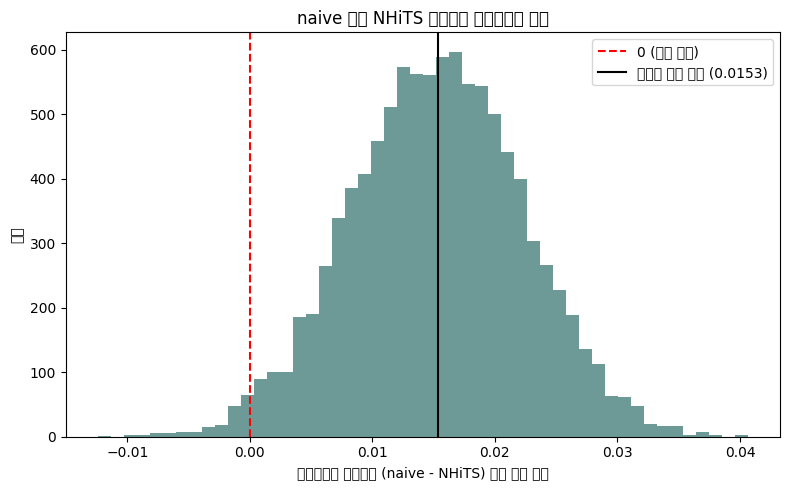

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(boot_means, bins=50, color="#2f6f6b", alpha=0.7)
plt.axvline(0, color="red", linestyle="--", label="0 (차이 없음)")
plt.axvline(diff.mean(), color="black", linestyle="-", label=f"관측된 평균 차이 ({diff.mean():.4f})")
plt.xlabel("부트스트랩 재표본별 (naive - NHiTS) 평균 오차 차이")
plt.ylabel("빈도")
plt.title("naive 대비 NHiTS 개선폭의 부트스트랩 분포")
plt.legend()
plt.tight_layout()
plt.savefig("06c_유의성검증_손.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. 결과 저장 (다운로드)

In [8]:
summary = pd.DataFrame([{
    "윈도우 수": n_windows,
    "naive_MAE": naive_errs.mean(),
    "NHiTS_MAE": nhits_errs.mean(),
    "개선률(%)": (naive_errs.mean() - nhits_errs.mean()) / naive_errs.mean() * 100,
    "부트스트랩_CI_하한": ci_low,
    "부트스트랩_CI_상한": ci_high,
    "Wilcoxon_p값": p_value,
    "유의미함(p<0.05)": p_value < 0.05,
}])
print(summary.to_string(index=False))
summary.to_csv("06c_유의성검증_요약_손.csv", index=False, encoding="utf-8-sig")

from google.colab import files
files.download("06c_유의성검증_요약_손.csv")
files.download("06c_유의성검증_손.png")

 윈도우 수  naive_MAE  NHiTS_MAE    개선률(%)  부트스트랩_CI_하한  부트스트랩_CI_상한  Wilcoxon_p값  유의미함(p<0.05)
   293   0.140648   0.125326 10.894075     0.001181     0.028811      0.00766          True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. 5단계 토픽 covariate 추가

로컬에서 이 시도가 스케일링 버그로 깨졌었다(MAE 73511 -- 학습구간이 전부 0인 상품이 많은데 검증구간에
1건만 나와도 (1-0)/(0+1e-9)로 스케일 폭발). **전역 최댓값으로 나누는 방식으로 고쳐서 다시 시도**한다.
비교 기준은 섹션4의 결과(naive 대비 9.8~10.9% 개선)다.

In [13]:
topics = pd.read_parquet("/content/패션_topics.parquet")  # 왼쪽 파일 탭에 업로드 필요
topics_dated = topics.merge(reviews[["review_id", "RDate_parsed", "ProductName"]], on="review_id", how="left")
topics_dated = topics_dated[topics_dated["RDate_parsed"].notna()].copy()
topics_dated["month"] = topics_dated["RDate_parsed"].dt.to_period("M").dt.to_timestamp()

WATCH_TOPIC_IDS = {11, 12, 2, 108, 113, 200, 203, 208}
topics_dated["is_watch"] = topics_dated["topic_id"].isin(WATCH_TOPIC_IDS)
watch_by_product_month = topics_dated[topics_dated["is_watch"]].groupby(["ProductName", "month"]).size()
print(f"신규 결함 토픽 리뷰 총 {topics_dated['is_watch'].sum()}건 / 패션 부정리뷰 {len(topics_dated)}건")

신규 결함 토픽 리뷰 총 901건 / 패션 부정리뷰 8013건


In [14]:
watch_cov_all = []
for key, s in zip(names_all, series_scaled_all_feat):
    dom = domain_of[key]
    full_idx = s.time_index
    if dom == "패션":
        product_name = key.replace("패션||", "")
        counts = watch_by_product_month.reindex(
            pd.MultiIndex.from_product([[product_name], full_idx], names=["ProductName", "month"]),
            fill_value=0,
        ).values
    else:
        counts = np.zeros(len(full_idx))
    watch_cov_all.append(TimeSeries.from_times_and_values(full_idx, counts))

# 버그 수정: 상품별 min/max 대신 전역 최댓값으로 나눠서 스케일 폭발 방지
global_watch_max = max(ts.values().max() for ts in watch_cov_all)
print(f"토픽 covariate 전역 최댓값: {global_watch_max}")

cov_scaled_all_feat2 = []
for i, watch_ts in enumerate(watch_cov_all):
    watch_scaled = TimeSeries.from_times_and_values(watch_ts.time_index, watch_ts.values() / global_watch_max)
    cov_scaled_all_feat2.append(cov_scaled_all_feat[i].stack(watch_scaled))
print("past covariate 차원:", cov_scaled_all_feat2[0].n_components, "(리뷰수1 + month_sin/cos2 + 토픽비중1)")

토픽 covariate 전역 최댓값: 4.0
past covariate 차원: 4 (리뷰수1 + month_sin/cos2 + 토픽비중1)


In [15]:
nhits_global3 = NHiTSModel(
    input_chunk_length=INPUT_LEN, output_chunk_length=OUTPUT_LEN,
    n_epochs=75, random_state=42,
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    pl_trainer_kwargs={"enable_progress_bar": False, "enable_model_summary": False},
)
nhits_global3.fit(series=train_target_all_feat, past_covariates=cov_scaled_all_feat2)

fashion_cov_scaled_all_feat2 = [cov_scaled_all_feat2[i] for i in fashion_idx_in_all]
nhits_global3_hist = nhits_global3.historical_forecasts(
    series=fashion_series_scaled_all_feat, past_covariates=fashion_cov_scaled_all_feat2,
    forecast_horizon=OUTPUT_LEN, stride=STRIDE, start=TRAIN_FRAC,
    retrain=False, last_points_only=False, verbose=False, num_samples=200,
)
print("토픽covariate 모델 학습+백테스트 완료")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:106: Total length of `list` across ranks is zero. Please make sure this was your intention.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=75` reached.
INFO:pytorch_lightn

토픽covariate 모델 학습+백테스트 완료


In [16]:
nhits3_errs, naive3_errs, n3 = [], [], 0
for i, nh_windows in enumerate(nhits_global3_hist):
    full_pd = fashion_series_all[i].to_series()
    for nh_w in nh_windows:
        actual = full_pd.reindex(nh_w.time_index).values
        nh_pred = nh_w.quantile(0.5).values().ravel() * (fashion_train_maxs_all[i] - fashion_train_mins_all[i]) + fashion_train_mins_all[i]
        naive_origin = nh_w.time_index[0] - pd.DateOffset(months=1)
        naive_val = full_pd.get(naive_origin, np.nan)
        if pd.isna(naive_val):
            continue
        n3 += 1
        nhits3_errs.append(np.abs(actual - nh_pred).mean())
        naive3_errs.append(np.abs(actual - naive_val).mean())

nhits3_errs, naive3_errs = np.array(nhits3_errs), np.array(naive3_errs)
print(f"윈도우 {n3}개 (293개여야 정상)")
print(f"naive MAE: {naive3_errs.mean():.4f}")
print(f"NHiTS(+토픽covariate) MAE: {nhits3_errs.mean():.4f} (섹션4 기준 NHiTS: {nhits_errs.mean():.4f})")
print(f"개선률(naive 대비): {(naive3_errs.mean()-nhits3_errs.mean())/naive3_errs.mean()*100:.1f}%")

윈도우 293개 (293개여야 정상)
naive MAE: 0.1406
NHiTS(+토픽covariate) MAE: 0.1319 (섹션4 기준 NHiTS: 0.1253)
개선률(naive 대비): 6.3%
